In [1]:
import pandas as pd

In [ ]:
#https://machinelearningmastery.com/time-series-forecasting-methods-in-python-cheat-sheet/

In [2]:
dataset=pd.read_csv("Tatacoffee13_21.csv",index_col="Date",parse_dates=True)

In [3]:
dataset.head()

,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65


In [4]:
dataset.isnull().sum()

Open     0
High     0
Low      0
Close    0
dtype: int64

In [5]:
import datetime as dt
start = dt.datetime(2021,9,1)
end = dt.datetime(2022,2,4)

In [6]:
df = dataset.loc[start:end] # picking only the daterange provided in above

In [7]:
stk_data = df

In [8]:
column='Close'

In [9]:
column

'Close'

In [10]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()

In [11]:
data1 = Ms.fit_transform(stk_data[[column]])

In [12]:
data1.shape

(81, 1)

In [15]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
from statsmodels.tsa.arima.model import ARIMA
# Creating loop to check how the model behaves for given parameter and evaluate rmse and mape metrics
#trends=['n','t','c','ct']
orders=[(1,1,1),(1,1,2),(2,1,1),(2,1,2),(1,2,1),(1,2,2),(2,2,1),(2,2,2),(3,1,1),(3,2,2),(3,3,2),(3,3,3)]
#orders = [(1,1,1),(1,1,2),(2,3,1),(2,2,2)]
for o in orders:
    model=ARIMA(data1, order=o)
    model_fit=model.fit()
    y_pred = model_fit.predict(0,len(data1)-1)  # This is prdicting similar length of series in y_test
    print("The order values are {}.".format(o))
    from stockFunctions import rmsemape # calling user defined function which contains metric calculation
    rmsemape(data1,y_pred)
    print("_______________")

The order values are (1, 1, 1).
RMSE-Testset: 0.12042529449358885
maPe-Testset: 13244655018278.89
_______________
The order values are (1, 1, 2).
RMSE-Testset: 0.11878916678354758
maPe-Testset: 13432644876391.352
_______________
The order values are (2, 1, 1).
RMSE-Testset: 0.11829770358854981
maPe-Testset: 13646049797210.229
_______________
The order values are (2, 1, 2).
RMSE-Testset: 0.11786867330137976
maPe-Testset: 13829060502597.549
_______________
The order values are (1, 2, 1).
RMSE-Testset: 0.12549289460751578
maPe-Testset: 12902615626433.385
_______________
The order values are (1, 2, 2).
RMSE-Testset: 0.12482538444442243
maPe-Testset: 12636554927480.154
_______________
The order values are (2, 2, 1).
RMSE-Testset: 0.12713341854347393
maPe-Testset: 11169897140842.482
_______________
The order values are (2, 2, 2).
RMSE-Testset: 0.12345629525034037
maPe-Testset: 13429776863722.828
_______________
The order values are (3, 1, 1).
RMSE-Testset: 0.11711763242501362
maPe-Testset: 1

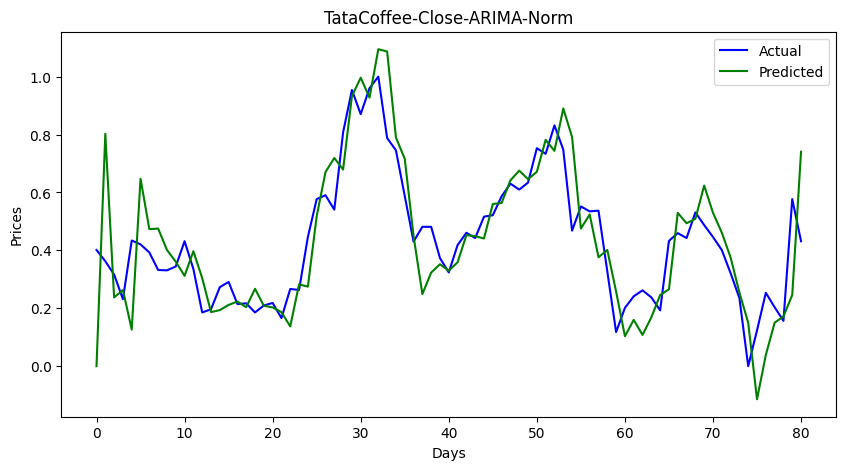

In [21]:
from stockFunctions import graph
graph(data1,y_pred,"Actual","Predicted","TataCoffee-Close-ARIMA-Norm","Days","Prices")

In [22]:
# Function does the same above for Acutal Test
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(data1,[column])  # this call creates data frame and fill with y_test value
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)  # this call inverse the scaler value from dataframe into original value. Scaler expects DataFrame data
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column]) #this call creates dataframe

In [23]:
# Function does the same above for Predicted Test
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])  #Creating df for predicted value
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable) #inversing the scaler data into Original value 
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column]) # creating data frame.

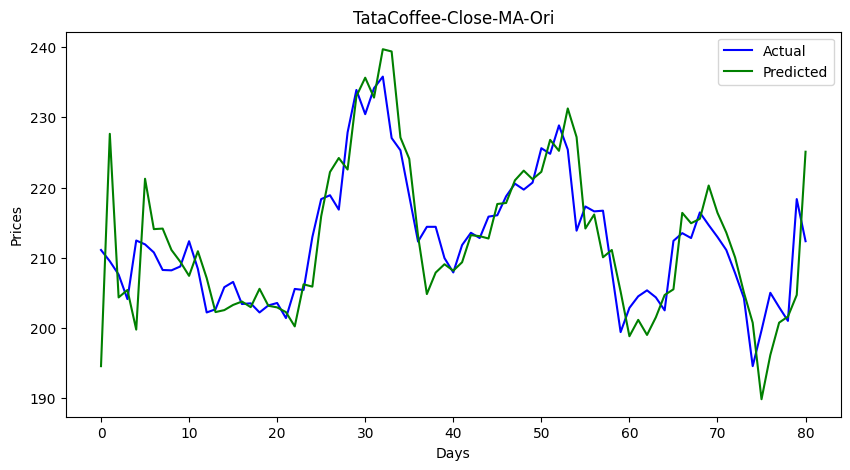

In [24]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-MA-Ori","Days","Prices")